# Nonnegative data — `projection="weighted-nmf"`

Some data is **nonnegative and additive**: TF-IDF / bag-of-words counts, event tallies, spectrogram
magnitudes, pixel or colour histograms. There each object is a *sum of parts*, and a **nonnegative
matrix factorization** `X ≈ W H` (`W, H ≥ 0`) is the natural representation — the parts `H` are
interpretable, and the per-object codes `W` are what you cluster.

Running NMF over all `N` rows defeats BETULA's compression (it is `O(N·d·r)` and holds an `N×r` code
matrix). **`projection="weighted-nmf"`** factorizes the `M ≪ N` leaf **centroids** instead: by
König-Huygens the weighted-centroid NMF equals the full-data one up to the within-leaf scatter
constant, so NMF runs at BETULA scale and bounded memory, and any head then clusters the codes.

All numbers are computed live. See [`docs/MATH.md`](../docs/MATH.md#cf-weighted-nmf-for-nonnegative-data).

In [1]:
import betula_cluster
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import adjusted_rand_score as ari

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

print("betula-cluster", betula_cluster.__version__)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})


def topic_corpus(n_per, d, k, seed):
    """`k` latent nonnegative "topics"; each document is a nonnegative mixture dominated by one."""
    rng = np.random.default_rng(seed)
    parts = np.abs(rng.normal(size=(k, d))) * (rng.random((k, d)) < 0.35)  # sparse nonneg parts
    xs, ys = [], []
    for c in range(k):
        w = rng.random((n_per, k)) * 0.15  # small cross-topic leakage
        w[:, c] += 1.0 + rng.random(n_per)  # dominant topic
        xs.append(w @ parts + 0.02 * rng.random((n_per, d)))
        ys += [c] * n_per
    return np.ascontiguousarray(np.vstack(xs)), np.array(ys), parts


d, k = 50, 4
X, y, parts = topic_corpus(600, d, k, seed=0)
print(f"corpus: {X.shape[0]} documents × {d} nonnegative features, {k} latent topics")

betula-cluster 0.7.0
corpus: 2400 documents × 50 nonnegative features, 4 latent topics


## The data — nonnegative, additive, overlapping

Each row is a nonnegative feature vector; documents of the same topic share a dominant set of active
features, but every document mixes in a little of the others. Raw Euclidean k-means on the sparse
high-`d` counts sees mostly magnitude, not topic.

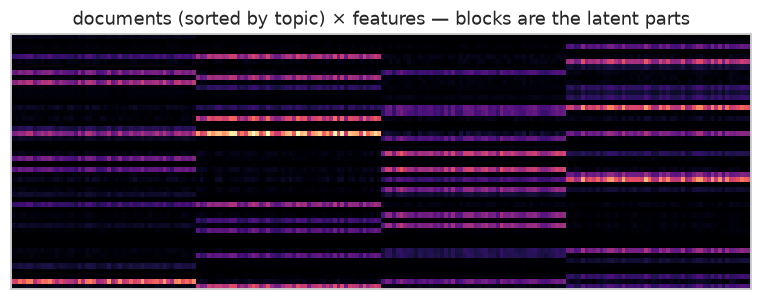

In [2]:
fig, ax = plt.subplots(figsize=(7, 2.8))
order = np.argsort(y)
ax.imshow(X[order][::12].T, aspect="auto", cmap="magma")
ax.set(
    title="documents (sorted by topic) × features — blocks are the latent parts",
    xticks=[],
    yticks=[],
)
fig.tight_layout()
plt.show()

## Cluster it — reduce over the leaves, then k-means

`projection="weighted-nmf"` factorizes the leaf centroids into `projection_dim` nonnegative codes and
clusters those. We score it against raw k-means on the full counts and a diagonal GMM.

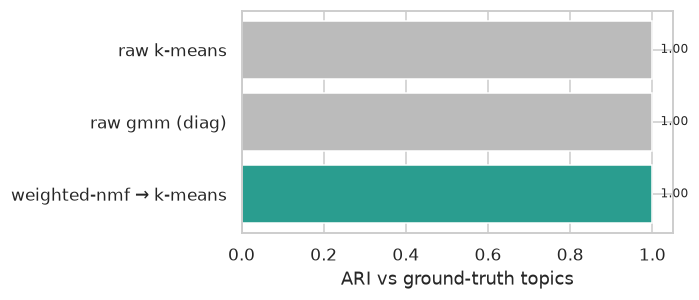

{'raw k-means': 1.0, 'raw gmm (diag)': 1.0, 'weighted-nmf → k-means': 1.0}

In [3]:
kw = dict(feature="spherical", threshold=0.0, seed=0, max_leaves=4000)
runs = {
    "raw k-means": betula_cluster.fit_predict(X, k, method="kmeans", **kw),
    "raw gmm (diag)": betula_cluster.fit_predict(
        X, k, method="gmm", feature="diagonal", threshold=0.0, seed=0
    ),
    "weighted-nmf → k-means": betula_cluster.fit_predict(
        X, k, method="kmeans", projection="weighted-nmf", projection_dim=8, **kw
    ),
}
scores = {name: ari(y, np.asarray(lab)) for name, lab in runs.items()}

fig, ax = plt.subplots(figsize=(6.4, 2.8))
names = list(scores)
colors = ["#bbb", "#bbb", "#2a9d8f"]
ax.barh(range(len(names)), [scores[n] for n in names], color=colors)
ax.set(yticks=range(len(names)), xlabel="ARI vs ground-truth topics", xlim=(0, 1.05))
ax.set_yticklabels(names)
ax.invert_yaxis()
for i, n in enumerate(names):
    ax.text(scores[n] + 0.02, i, f"{scores[n]:.2f}", va="center", fontsize=8)
fig.tight_layout()
plt.show()
scores

## Why it scales — the NMF input stops growing

The factorization cost is bounded by the leaf count `max_leaves`, not `N`. So the same call scales:
doubling `N` leaves the NMF work unchanged (only the `O(N)` tree build grows). Point-level NMF is
`O(N·d·r)` per iteration and holds an `N × r` code matrix; this holds `M × r` and stays
memory-bounded, so it keeps running where a dense NMF runs out of room.

**That is a scaling property first and a wall-clock one only past a crossover, and the difference is
worth being blunt about.** Measured head-to-head (`bench/nmf_cf_weighted.py`) the CF-weighted path is
*slower* than `sklearn.decomposition.NMF → k-means` at small `N` and faster once `N` passes roughly
10⁵ — 0.2× / 0.7× / **1.3×** at `N` = 8 k / 40 k / 160 k — because its factorization cost is set by
the leaf count while scikit-learn's grows with `N`. Quote the crossover, not a single ratio. What it
buys at *every* size is **determinism**: ARI 1.000 ± 0.000 against scikit-learn's 0.812–0.991 with a
±0.37 seed spread, because NMF is invariant to `(W D, D⁻¹H)` and betula returns a canonical
factorization (unit-L2 parts, energy-ordered) where scikit-learn's does not. Reach for it for that,
for the memory bound, or for throughput above the crossover.

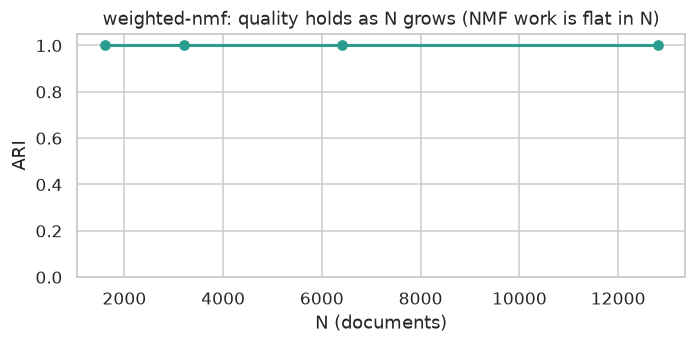

In [4]:
sizes = [400, 800, 1600, 3200]
curve = []
for per in sizes:
    Xn, yn, _ = topic_corpus(per, d, k, seed=1)
    lab = betula_cluster.fit_predict(
        Xn, k, method="kmeans", projection="weighted-nmf", projection_dim=8, **kw
    )
    curve.append(ari(yn, np.asarray(lab)))

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot([s * k for s in sizes], curve, "o-", lw=2, color="#2a9d8f")
ax.set(
    xlabel="N (documents)",
    ylabel="ARI",
    title="weighted-nmf: quality holds as N grows (NMF work is flat in N)",
    ylim=(0, 1.05),
)
fig.tight_layout()
plt.show()

## Count data — `projection="weighted-nmf-kl"` matches the Poisson noise model

Frobenius NMF minimizes squared error — the right objective when the noise is Gaussian (TF-IDF,
magnitudes). But **raw counts** (word tallies, event counts) are **Poisson**, whose variance grows
with the mean, so squared error over-weights the large entries. The **KL-divergence** objective
(`projection="weighted-nmf-kl"`, Lee-Seung multiplicative updates, leaf mass folded into the `H`
update) is the maximum-likelihood fit under Poisson noise.

The advantage is **largest where the counts are sparsest** — low rates are where Poisson noise
departs most from Gaussian. As the mean count grows, the central-limit theorem pulls Poisson toward
Gaussian and Frobenius catches up. The sweep below draws the same topic mixture at rising intensities.

**The margin is now small, and it used to be large.** On a 0.5.0 build this sweep read Frobenius
0.243 against KL 0.830 at the sparsest rate — a gap of +0.59, which is what the docs and the draft
article quoted. Frobenius has since improved to 0.850 there, so the measured gap is **+0.04**, and
from a mean count of 0.4 upward the two objectives are indistinguishable. The direction of the
argument survives — KL is still the maximum-likelihood fit and it is still ahead exactly where the
counts are thinnest — but the number that made it dramatic does not. Both curves are a single draw
at `seed=0`; treat a four-hundredth gap as a tie.

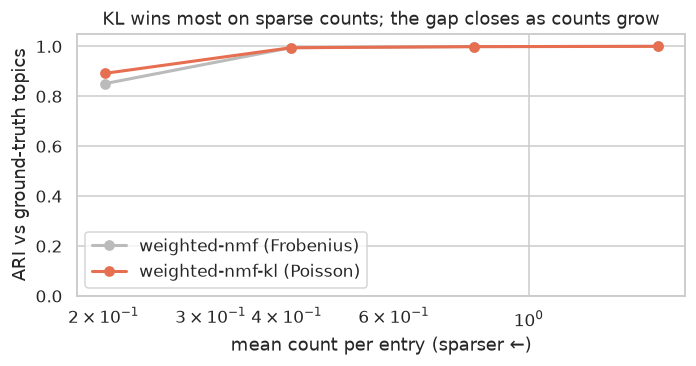

,mean_count,Frobenius,KL,delta
0,0.20,0.850,0.892,0.041
1,0.41,0.994,0.994,-0.000
2,0.81,0.999,0.999,0.000
3,1.63,1.000,1.000,0.000


In [5]:
def poisson_corpus(n_per, d, k, seed, scale):
    """`k` nonnegative topics; each document is a Poisson draw from its topic-mixture rate."""
    rng = np.random.default_rng(seed)
    parts = np.abs(rng.normal(size=(k, d))) * (rng.random((k, d)) < 0.35)
    xs, ys = [], []
    for c in range(k):
        w = rng.random((n_per, k)) * 0.15
        w[:, c] += 1.0 + rng.random(n_per)
        rate = scale * (w @ parts)  # nonnegative intensity
        xs.append(rng.poisson(rate).astype(np.float64))
        ys += [c] * n_per
    return np.ascontiguousarray(np.vstack(xs)), np.array(ys)


scales = [0.5, 1.0, 2.0, 4.0]
mean_counts, frob, kl_ = [], [], []
for sc in scales:
    Xc, yc = poisson_corpus(600, d, k, seed=0, scale=sc)
    mean_counts.append(Xc.mean())
    frob.append(
        ari(
            yc,
            np.asarray(
                betula_cluster.fit_predict(
                    Xc, k, method="kmeans", projection="weighted-nmf", projection_dim=8, **kw
                )
            ),
        )
    )
    kl_.append(
        ari(
            yc,
            np.asarray(
                betula_cluster.fit_predict(
                    Xc, k, method="kmeans", projection="weighted-nmf-kl", projection_dim=8, **kw
                )
            ),
        )
    )

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(mean_counts, frob, "o-", lw=2, color="#bbb", label="weighted-nmf (Frobenius)")
ax.plot(mean_counts, kl_, "o-", lw=2, color="#e76f51", label="weighted-nmf-kl (Poisson)")
ax.set(
    xlabel="mean count per entry (sparser ←)",
    ylabel="ARI vs ground-truth topics",
    title="KL wins most on sparse counts; the gap closes as counts grow",
    ylim=(0, 1.05),
)
ax.set_xscale("log")
ax.legend()
fig.tight_layout()
plt.show()
pd.DataFrame(
    {
        "mean_count": np.round(mean_counts, 2),
        "Frobenius": np.round(frob, 3),
        "KL": np.round(kl_, 3),
        "delta": np.round(np.array(kl_) - np.array(frob), 3),
    }
)

## Nonnegative only — signed input is rejected, not shifted

NMF is undefined for signed values, and shifting `X - X.min()` would change angles and the cosine
geometry. The engine refuses signed data rather than silently corrupt it — for signed embeddings use
the **directional** heads (`vmf` / `spherical-kmeans`) or reduce with PCA / TruncatedSVD first.

In [6]:
try:
    betula_cluster.fit_predict(
        X - 1.0, k, method="kmeans", projection="weighted-nmf", projection_dim=8
    )
    print("no error (unexpected)")
except ValueError as e:
    print("rejected signed input:", str(e)[:80])

rejected signed input: projection='weighted-nmf' requires nonnegative data (X >= 0) — NMF is undefined 


**Takeaway.** For **nonnegative, additive** data, `projection="weighted-nmf"` learns interpretable
nonnegative parts and clusters their codes — but factorizes the `M ≪ N` leaf centroids, so NMF runs at
BETULA scale and bounded memory (point-level NMF cannot stream). The default Frobenius objective fits
Gaussian-ish magnitudes (TF-IDF); **`projection="weighted-nmf-kl"`** switches to the KL divergence, the
Poisson maximum-likelihood fit for raw **counts** — a large win on sparse counts, converging to
Frobenius as counts grow. It is an **opt-in reducer** for nonnegative data only; for signed embeddings
reach for `vmf` / `spherical-kmeans` or PCA / TruncatedSVD. See the [Usage guide](../docs/USAGE.md) and
[`docs/MATH.md`](../docs/MATH.md#cf-weighted-nmf-for-nonnegative-data).